In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [60]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [53]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [20]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [15]:
C = torch.randn((27,2))
C

tensor([[ 0.6644, -0.5323],
        [-1.2706, -1.9312],
        [ 1.5352, -1.6063],
        [-0.2344, -0.2000],
        [-0.2618,  0.6643],
        [ 0.1468, -0.4138],
        [ 0.4802,  1.1223],
        [-0.5472, -1.0542],
        [-0.2762, -0.0447],
        [ 2.1601,  0.1808],
        [ 0.3025, -1.0577],
        [ 0.6458,  1.5000],
        [ 0.9972,  0.3217],
        [ 0.1033, -0.9004],
        [-1.3546,  0.5025],
        [ 0.0330,  1.1800],
        [ 0.9717, -1.8259],
        [ 1.8869, -0.1899],
        [-0.5306,  0.1754],
        [ 0.4186,  0.4360],
        [ 0.1856, -0.2620],
        [ 0.4473,  0.1081],
        [ 0.4140,  0.3831],
        [ 1.2748, -0.4656],
        [ 1.0631,  1.0131],
        [-0.5725,  0.7831],
        [-0.5266,  0.2190]])

In [19]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [21]:
emb

tensor([[[ 0.6644, -0.5323],
         [ 0.6644, -0.5323],
         [ 0.6644, -0.5323]],

        [[ 0.6644, -0.5323],
         [ 0.6644, -0.5323],
         [ 0.1468, -0.4138]],

        [[ 0.6644, -0.5323],
         [ 0.1468, -0.4138],
         [ 0.1033, -0.9004]],

        [[ 0.1468, -0.4138],
         [ 0.1033, -0.9004],
         [ 0.1033, -0.9004]],

        [[ 0.1033, -0.9004],
         [ 0.1033, -0.9004],
         [-1.2706, -1.9312]],

        [[ 0.6644, -0.5323],
         [ 0.6644, -0.5323],
         [ 0.6644, -0.5323]],

        [[ 0.6644, -0.5323],
         [ 0.6644, -0.5323],
         [ 0.0330,  1.1800]],

        [[ 0.6644, -0.5323],
         [ 0.0330,  1.1800],
         [ 0.9972,  0.3217]],

        [[ 0.0330,  1.1800],
         [ 0.9972,  0.3217],
         [ 2.1601,  0.1808]],

        [[ 0.9972,  0.3217],
         [ 2.1601,  0.1808],
         [ 0.4140,  0.3831]],

        [[ 2.1601,  0.1808],
         [ 0.4140,  0.3831],
         [ 2.1601,  0.1808]],

        [[ 0.4140,  0

In [31]:
# Different ways to restructure embeddings to perform operations on W1 and b1

    # emb[:, 0, :] gets the 32 by 2 embeddings of just the first character.
    # concatenating them will combine the embeddings of all three characters in one array
    # we want to concatenate them across dimension 1: 3 (32 x 3) --> (32 x 6)

torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape # inefficient as it creates new memory
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

torch.Size([32, 6])

In [22]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [39]:
h = emb.view(32, 6) @ W1 + b1

torch.Size([32, 100])

***Non-Scratch Work: Actual Meat of the Video!***

In [47]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [63]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [49]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many characters fo we take to predict the next one
    X, Y = [], []

    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)

            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [50]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [51]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

In [52]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [53]:
for p in parameters:
    p.requires_grad = True

In [54]:
# learning rate
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [55]:
lri = []
lossi = []
stepi = []

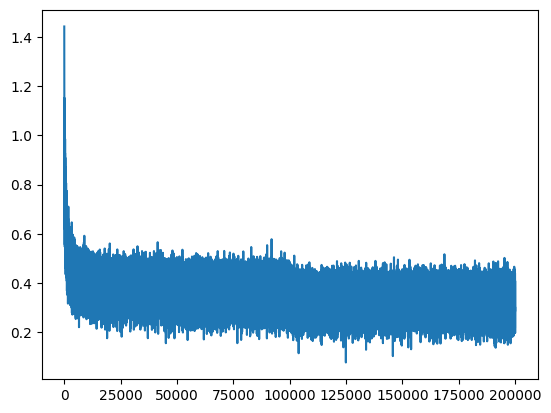

In [56]:
for i in range(200000):

    # minibatch construct (used to speed up training process)
    ix = torch.randint(0, Xtr.shape[0], (32, ))

    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())
    stepi.append(i)
    lossi.append(loss.log10().item())

plt.plot(stepi, lossi)

In [57]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1339, grad_fn=<NllLossBackward0>)

In [58]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1703, grad_fn=<NllLossBackward0>)

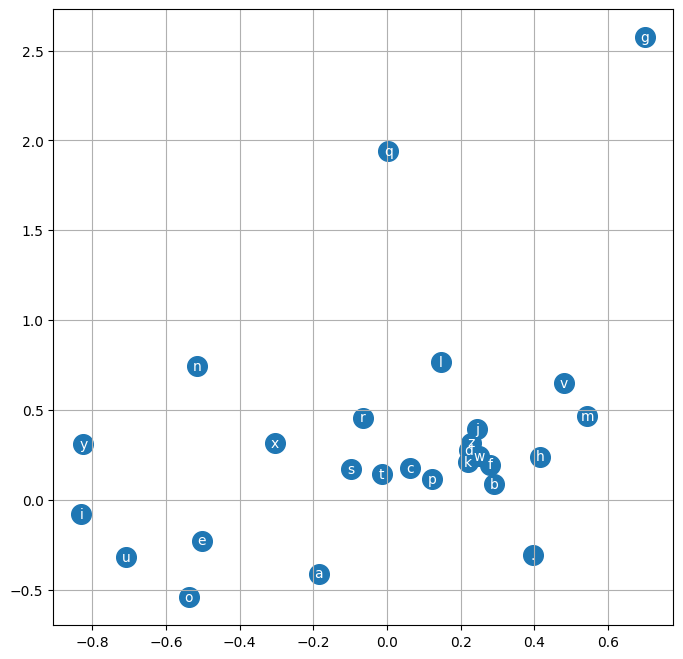

In [32]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid("minor")

* To avoid model overfitting to training data, the data is often split into three: training split (80%), dev/ validation split (10%), test split (10%)
* Training split is used to optimize the model parameters
* Dev/ validation split is used for development over all the hyperparameters of the model (size of the hidden layer, embedding, strength of regularization, etc.)
* Test split is used to evaluate the performance of the model at the end
    * Only allowed to get the loss on the test split a few times, because the more you test, the more the model is learning from the test and cannot be reliably tested on again. Risk overfitting to it as well


In [65]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [68]:
# Sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmahfato.
hariffirrichelly.
skanden.
jazhith.
amerric.
kaqui.
nellara.
chaiir.
kaleigh.
ham.
jorn.
quintis.
lilea.
jamilio.
jero.
dearynn.
jaceenigsan.
edde.
iia.
gine.
